In [23]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_csv('train.csv')
df

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0
...,...,...,...,...,...,...
404285,404285,433578,379845,How many keywords are there in the Racket prog...,How many keywords are there in PERL Programmin...,0
404286,404286,18840,155606,Do you believe there is life after death?,Is it true that there is life after death?,1
404287,404287,537928,537929,What is one coin?,What's this coin?,0
404288,404288,537930,537931,What is the approx annual cost of living while...,I am having little hairfall problem but I want...,0


In [3]:
new_df=df.sample(40000)
new_df

,id,qid1,qid2,question1,question2,is_duplicate
91540,91540,25929,153386,How do I be a good friend?,How do I get a good friend?,0
71008,71008,122271,122272,What are the best aspects of working at Nation...,What are the best aspects of working at Nation...,0
42990,42990,77390,77391,How much data does it take to stream music?,With Rdio entering the Indian music streaming ...,0
371788,371788,269317,233024,What is the output of this program? ?,What is the output of this program?,0
184537,184537,281920,281921,How can you know if you’re pregnant without us...,How do you know you're pregnant without a test?,1
...,...,...,...,...,...,...
326070,326070,452342,452343,What does a graduate student get out of dissem...,"As a new graduate student, how does one not be...",0
116036,116036,10942,1441,Where can I find a professional hacker?,How can I hire a hacker?,1
330353,330353,457109,457110,How can I see a psychologist free?,How can I talk to a psychologist for free?,1
119146,119146,193521,193522,How can I calculate this limit?,How do I calculate this limit?,0


In [4]:
new_df['q1_len']=new_df['question1'].str.len()
new_df['q2_len']=new_df['question2'].str.len()
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
91540,91540,25929,153386,How do I be a good friend?,How do I get a good friend?,0,26,27
71008,71008,122271,122272,What are the best aspects of working at Nation...,What are the best aspects of working at Nation...,0,58,58
42990,42990,77390,77391,How much data does it take to stream music?,With Rdio entering the Indian music streaming ...,0,43,146
371788,371788,269317,233024,What is the output of this program? ?,What is the output of this program?,0,37,35
184537,184537,281920,281921,How can you know if you’re pregnant without us...,How do you know you're pregnant without a test?,1,57,47


In [5]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40000 entries, 91540 to 77657
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            40000 non-null  int64 
 1   qid1          40000 non-null  int64 
 2   qid2          40000 non-null  int64 
 3   question1     40000 non-null  object
 4   question2     40000 non-null  object
 5   is_duplicate  40000 non-null  int64 
 6   q1_len        40000 non-null  int64 
 7   q2_len        40000 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 2.7+ MB


In [6]:
new_df['q1_num_words']=new_df['question1'].apply(lambda x: len(x.split(' ')))
new_df['q2_num_words']=new_df['question2'].apply(lambda x: len(x.split(' ')))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
91540,91540,25929,153386,How do I be a good friend?,How do I get a good friend?,0,26,27,7,7
71008,71008,122271,122272,What are the best aspects of working at Nation...,What are the best aspects of working at Nation...,0,58,58,10,10
42990,42990,77390,77391,How much data does it take to stream music?,With Rdio entering the Indian music streaming ...,0,43,146,9,27
371788,371788,269317,233024,What is the output of this program? ?,What is the output of this program?,0,37,35,8,7
184537,184537,281920,281921,How can you know if you’re pregnant without us...,How do you know you're pregnant without a test?,1,57,47,11,9


In [7]:
def common_words(row):
    w1=set(map(lambda x: x.lower().strip(),row['question1'].split()))
    w2=set(map(lambda x: x.lower().strip(),row['question2'].split()))
    return len(w1&w2)

In [8]:
new_df['common_words']=new_df.apply(common_words,axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words
91540,91540,25929,153386,How do I be a good friend?,How do I get a good friend?,0,26,27,7,7,6
71008,71008,122271,122272,What are the best aspects of working at Nation...,What are the best aspects of working at Nation...,0,58,58,10,10,9
42990,42990,77390,77391,How much data does it take to stream music?,With Rdio entering the Indian music streaming ...,0,43,146,9,27,2
371788,371788,269317,233024,What is the output of this program? ?,What is the output of this program?,0,37,35,8,7,7
184537,184537,281920,281921,How can you know if you’re pregnant without us...,How do you know you're pregnant without a test?,1,57,47,11,9,7


In [9]:
def total_words(row):
    w1=set(map(lambda x: x.lower().strip(),row['question1'].split()))
    w2=set(map(lambda x: x.lower().strip(),row['question2'].split()))
    return len(w1)+len(w2)

In [10]:
new_df['total_words']=new_df.apply(total_words,axis=1)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec=TfidfVectorizer(max_features=4000)

In [12]:
ques_df=new_df[['question1','question2']]
questions=list(ques_df['question1'])+list(ques_df['question2'])
Q1_arr,Q2_arr=np.vsplit(vec.fit_transform(ques_df).toarray(),2)

In [13]:
Q1_arr,Q2_arr=np.vsplit(vec.fit_transform(questions).toarray(),2)
Tempdf1=pd.DataFrame(Q1_arr,index=ques_df.index)
Tempdf2=pd.DataFrame(Q2_arr,index=ques_df.index)
Tempdf=pd.concat([Tempdf1,Tempdf2],axis=1)
Tempdf.head()

,0,1,2,3,4,5,6,7,8,9,...,3990,3991,3992,3993,3994,3995,3996,3997,3998,3999
91540,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71008,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
371788,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
184537,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
finaldf=new_df.drop(['id','qid1','qid2','question1','question2'],axis=1)
finaldf.head()

,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,total_words
91540,0,26,27,7,7,6,14
71008,0,58,58,10,10,9,20
42990,0,43,146,9,27,2,35
371788,0,37,35,8,7,7,15
184537,1,57,47,11,9,7,20


In [15]:
finaldf['word_share']=round(finaldf['common_words']/finaldf['total_words'],2)
finaldf.head()

,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,total_words,word_share
91540,0,26,27,7,7,6,14,0.43
71008,0,58,58,10,10,9,20,0.45
42990,0,43,146,9,27,2,35,0.06
371788,0,37,35,8,7,7,15,0.47
184537,1,57,47,11,9,7,20,0.35


In [16]:
finaldf=pd.concat([finaldf,Tempdf],axis=1)
finaldf.head()

,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,total_words,word_share,0,1,...,3990,3991,3992,3993,3994,3995,3996,3997,3998,3999
91540,0,26,27,7,7,6,14,0.43,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71008,0,58,58,10,10,9,20,0.45,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42990,0,43,146,9,27,2,35,0.06,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
371788,0,37,35,8,7,7,15,0.47,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
184537,1,57,47,11,9,7,20,0.35,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


maximum length in question1:  430
minimum length in question1:  1
average length of question1:  59.7843


<Figure size 1800x800 with 0 Axes>

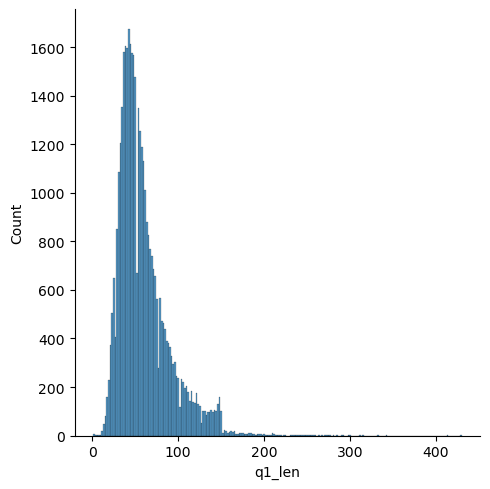

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(18,8))
print('maximum length in question1: ',finaldf['q1_len'].max())
print('minimum length in question1: ',finaldf['q1_len'].min())
print('average length of question1: ',np.mean(finaldf['q1_len']))
sns.displot(finaldf['q1_len'])



maximum length in question2:  1169
minimum length in question2:  4
average length of question2:  60.484025


<Figure size 1800x800 with 0 Axes>

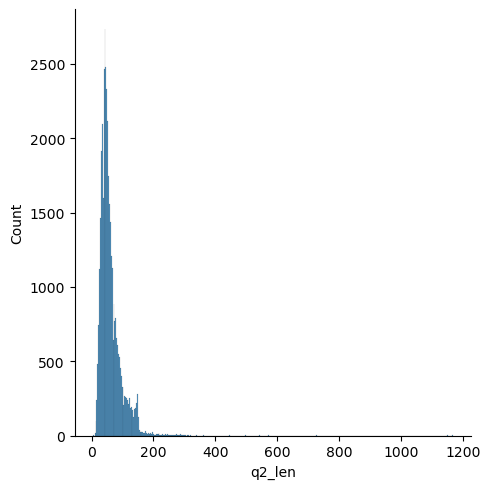

In [18]:
plt.figure(figsize=(18,8))
print('maximum length in question2: ',finaldf['q2_len'].max())
print('minimum length in question2: ',finaldf['q2_len'].min())
print('average length of question2: ',np.mean(finaldf['q2_len']))
sns.displot(finaldf['q2_len'])

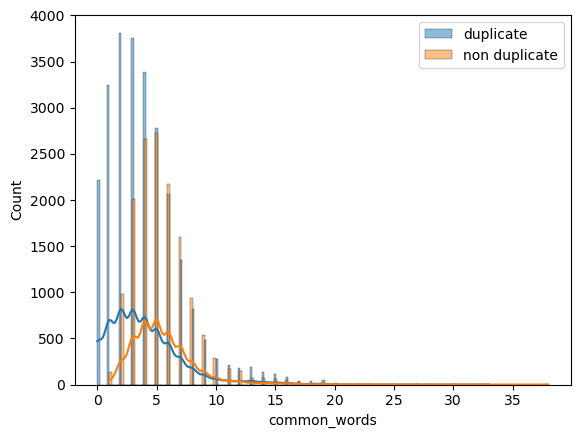

In [21]:
sns.histplot(finaldf[finaldf['is_duplicate']==0]['common_words'],label='duplicate',kde=True)
sns.histplot(finaldf[finaldf['is_duplicate']==1]['common_words'],label='non duplicate',kde=True)
plt.legend()
plt.show()


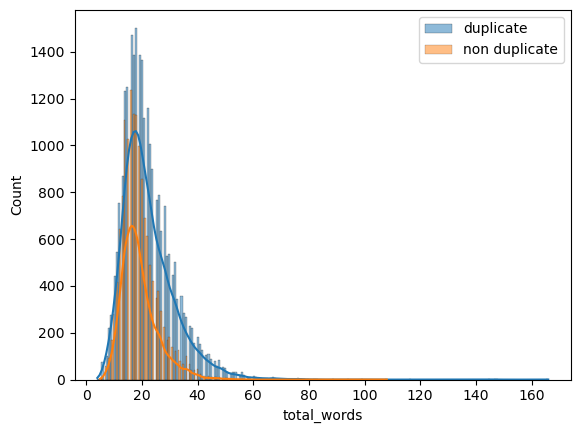

In [22]:
sns.histplot(finaldf[finaldf['is_duplicate']==0]['total_words'],label='duplicate',kde=True)
sns.histplot(finaldf[finaldf['is_duplicate']==1]['total_words'],label='non duplicate',kde=True)
plt.legend()
plt.show()


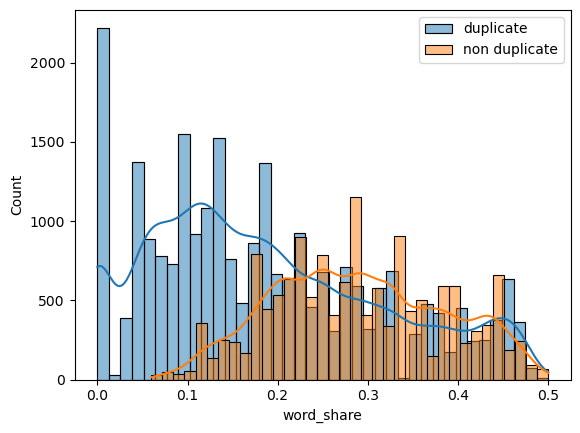

In [24]:
sns.histplot(finaldf[finaldf['is_duplicate']==0]['word_share'],label='duplicate',kde=True)
sns.histplot(finaldf[finaldf['is_duplicate']==1]['word_share'],label='non duplicate',kde=True)
plt.legend()
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(finaldf.iloc[:,1:].values,finaldf.iloc[:,0].values,test_size=0.25,random_state=42)
x_train

array([[ 79., 115.,  15., ...,   0.,   0.,   0.],
       [220.,  43.,  43., ...,   0.,   0.,   0.],
       [ 36.,  39.,   6., ...,   0.,   0.,   0.],
       ...,
       [ 45.,  45.,   9., ...,   0.,   0.,   0.],
       [ 53.,  54.,  10., ...,   0.,   0.,   0.],
       [ 25., 107.,   4., ...,   0.,   0.,   0.]], shape=(30000, 8007))

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
print(accuracy_score(y_test,rf.predict(x_test)))

0.7727


In [28]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(x_train,y_train)
print(accuracy_score(y_test,xgb.predict(x_test)))

0.7702
